## 1. Imports

### Import the ISM and expression-model components

This notebook combines sequence construction, expression-model inference, variant interpretation, and in-silico mutagenesis.

`ISM` generates substitutions and deletions within a selected region of an `AnnotatedSequence`, stores them in a Polars dataframe, and provides methods for scoring and visualization. `VariantInterpreter` connects sequence pairs to a loaded `SequenceModel` and a scorer. `TrackFeatureScorer` measures the predicted change in a model track over a named sequence feature.

`Genome` retrieves sequence and annotations from a FASTA and optional GTF file. `DescriptionLookup` selects experimental metadata used as the model’s textual condition. The standard-library `dataclass` decorator is used later for a small container holding gene coordinates.

In [27]:
import os
from dataclasses import dataclass

from gena_expression.ism import ISM
from gena_expression.scoring import VariantInterpreter, TrackFeatureScorer, TrackWindowScorer
from gena_expression.contexts import Genome
from gena_expression.conditions import DescriptionLookup
from gena_expression.inference import SequenceModel

## 2. Paths and model configuration

### Configure the model, tokenizers, genome, and data paths

This cell defines all filesystem locations and inference constants used later in the notebook. Paths marked with `CHANGE THIS LINE` must point to files available in the current environment.

`MODEL_CLS` uses the `file.py::ClassName` format understood by `SequenceModel.load()`. Here it identifies the `ExpressionCounts` class inside `expression_model_final.py`.

The main inference parameters are:

- `dna_max_seq_len`: maximum number of DNA tokens supplied to the model.
- `desc_max_seq_len`: maximum tokenized length of the experimental description.
- `NUM_BEFORE`: desired number of DNA tokens before the tokenization center.
- `TOKEN_LEN_FOR_FETCH`: base-pair estimate used when constructing enough sequence around that center.
- `DEVICE`: PyTorch device on which the model will run.

In this notebook, `NUM_BEFORE * TOKEN_LEN_FOR_FETCH` equals `10,220` bp. The genomic sequence is constructed so that the SOX2 transcription start site occurs at that sequence-local coordinate.

`GENALM_HOME` points the original GENA-LM code to its project root and must be stored as a string environment variable.


In [ ]:
# Paths and constants used by later cells

from pathlib import Path

GENA_LM_ROOT = Path("/workspace-SR003.nfs2/estsoi/CAGI5_benchmark") / "GENA_LM" # CHANGE THIS LINE

EXPRESSION_TASK_DIR = GENA_LM_ROOT / "downstream_tasks" / "expression_prediction"

MODEL_CLS = EXPRESSION_TASK_DIR / "expression_model_final.py"
MODEL_CLS = f"{MODEL_CLS}::ExpressionCounts"

MODEL_CHECKPOINT = Path("/workspace-SR003.nfs2/estsoi/CAGI5_benchmark") / "models" / "expression_model_v1-2" / "pytorch_model.bin" # CHANGE THIS LINE
MODEL_CONFIG = EXPRESSION_TASK_DIR / "inference_example_config.yaml" # CHANGE THIS LINE
DNA_TOKENIZER = GENA_LM_ROOT / "data" / "tokenizers" / "t2t_1000h_multi_32k"
DESCRIPTION_TOKENIZER = "Qwen/Qwen3-Embedding-0.6B"

DATA_DIR = Path("../data").resolve()
DESCRIPTION_DIR = DATA_DIR / "real_descriptions"

GENOME_FASTA = Path("/home/jovyan/.cache/mpramnist/data/Kircher/hg38.fa") # CHANGE THIS LINE
GENOME_ANNOTATION = Path(
    "/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/"
    "downstream_tasks/expression_prediction/datasets/data/genomes/hg38/"
    "gencode.v29.primary_assembly.annotation_UCSC_names.gtf"
) # CHANGE THIS LINE

DEVICE = "cuda:5"
os.environ["GENALM_HOME"] = Path('../../../../..').resolve().__str__() # CHANGE THIS LINE

NUM_BEFORE = 511
TOKEN_LEN_FOR_FETCH = 20

## 3. Load the model and create an interpreter

### Initialize the expression model

`SequenceModel.load()` constructs the complete inference stack in one operation. Its arguments specify:

- `model_cls`: Python file or module and the model class name.
- `checkpoint`: trained model weights.
- `config`: Hydra configuration used to instantiate the model.
- `dna_tokenizer`: tokenizer for genomic sequence.
- `description_tokenizer`: tokenizer for condition metadata.
- `dna_max_seq_len` and `desc_max_seq_len`: maximum DNA and description token lengths.
- `num_before`: placement of the sequence center within the DNA token sequence.
- `token_len_for_fetch`: base-pair estimate used by centered sequence preparation.
- `device`: CPU or CUDA device.

Under the hood, the loader dynamically imports `ExpressionCounts`, reads its configuration and checkpoint, loads both tokenizers, moves the model to the selected device, and prepares it for inference.

`VariantInterpreter` is a scoring facade around the loaded model. It accepts reference/alternative `SequencePair` objects, runs both alleles through the model, and passes the resulting predictions to a scorer.


In [3]:
model = SequenceModel.load(
    model_cls=MODEL_CLS,
    checkpoint=MODEL_CHECKPOINT,
    config=MODEL_CONFIG,
    dna_tokenizer=DNA_TOKENIZER,
    description_tokenizer=DESCRIPTION_TOKENIZER,
    dna_max_seq_len=1024,
    num_before=NUM_BEFORE,
    desc_max_seq_len=510,
    token_len_for_fetch=TOKEN_LEN_FOR_FETCH,
    device=DEVICE,
)

interpreter = VariantInterpreter(model)

/home/jovyan/miniconda3/envs/api/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/gena_expression/inference/model.py:162: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(config_path.parents[0])):


Using ModernGENA from AIRI-Institute/moderngena-large


Flash Attention 2 only supports torch.float16 and torch.bfloat16 dtypes, but the current dype in ModernBertModel is torch.float32. You should run training or inference using Automatic Mixed-Precision via the `with torch.autocast(device_type='torch_device'):` decorator, or load the model with the `torch_dtype` argument. Example: `model = AutoModel.from_pretrained("openai/whisper-tiny", attn_implementation="flash_attention_2", torch_dtype=torch.float16)`


missing: 0 []
unexpected: 3 ['decoder.bias', 'head.dense.weight', 'head.norm.weight']
mismatched: []
bert dropouts: {'attention_dropout': 0.1, 'embedding_dropout': 0.1, 'mlp_dropout': 0.1}
qwen dropouts: {'attention_dropout': 0.1}
[desc_model] unfrozen transformer blocks: [24, 25, 26, 27] (total blocks=28)
[desc_model] backbone.norm trainable: True (trainable params=1,024)
[desc_model] trainable params: 62,924,800 / 595,776,512
[desc_model] trainable tensors: 45
  - layers.24.self_attn.q_proj.weight
  - layers.24.self_attn.k_proj.weight
  - layers.24.self_attn.v_proj.weight
  - layers.24.self_attn.o_proj.weight
  - layers.24.self_attn.q_norm.weight
  - layers.24.self_attn.k_norm.weight
  - layers.24.mlp.gate_proj.weight
  - layers.24.mlp.up_proj.weight
  - layers.24.mlp.down_proj.weight
  - layers.24.input_layernorm.weight
  - layers.24.post_attention_layernorm.weight
  - layers.25.self_attn.q_proj.weight
  - layers.25.self_attn.k_proj.weight
  - layers.25.self_attn.v_proj.weight
  - l

## 4. Genome and condition metadata

### Prepare genomic sequence access and experimental descriptions

`Genome` connects a reference FASTA to an optional genome annotation:

- `fasta_path` points to the indexed reference genome.
- `annotation` supplies GTF features such as genes and transcripts.
- Optional arguments can specify the genome build, chromosome naming convention, and FASTA handle caching.

`Genome.sequence()` will later return an `AnnotatedSequence`, preserving both sequence coordinates and overlapping GTF annotations. Internally, genome intervals use 0-based, half-open coordinates.

`DescriptionLookup` searches JSON metadata files for the requested keys. The dictionaries passed under `K562`, `HepG2`, and `H1` are key-specific filters, ensuring that each cell type resolves to the requested record ID.

The selection is deterministic: when several JSON files match, the same key and seed choose the same record. `lookup["H1"]` returns the selected metadata dictionary, which the model converts into its textual experimental condition.


In [ ]:
genome = Genome(
    fasta_path=GENOME_FASTA,
    annotation=GENOME_ANNOTATION,
)

lookup = DescriptionLookup(
    json_dir=DESCRIPTION_DIR,
    keys=["K562", "HepG2", "H1"],
    K562={"id": "ENCFF578UUD"},
    HepG2={"id": "ENCFF588KDY"},
    H1={"id": "ENCFF081FQX"},
)

/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/gena_expression/contexts/genome.py:437: RuntimeWarning: Plain GTF/GFF annotations are not supported directly for fast interval queries; using existing compressed annotation /workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/genomes/hg38/gencode.v29.primary_assembly.annotation_UCSC_names.gtf.gz. debug={'plain_path': '/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/genomes/hg38/gencode.v29.primary_assembly.annotation_UCSC_names.gtf', 'compressed_path': '/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/genomes/hg38/gencode.v29.primary_assembly.annotation_UCSC_names.gtf.gz'}
  return _TabixGtfAnnotation(cls._ensure_tabix_gtf(path))
/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/

## 5. Define the SOX2 interval

### Store the genomic coordinates of the example gene

`gene_coords` is a small notebook-specific data class containing:

- `gene_name`: human-readable gene identifier.
- `chrom`: reference chromosome.
- `TSS`: transcription start site.
- `TES`: transcription end site.
- `strand`: genomic orientation.

The SOX2 example is on the positive strand, so its transcription start occurs at the lower genomic coordinate.

The `Genome` API interprets interval coordinates as 0-based and half-open. Coordinates obtained from another source should therefore be converted if that source uses a 1-based convention.


In [24]:
@dataclass
class gene_coords:
    gene_name: str
    chrom: str
    TSS: int
    TES: int
    strand: str

In [25]:
SOX2 = gene_coords(
    gene_name='sox2',
    chrom='chr3',
    TSS=181711924,
    TES=181714436,
    strand='+'
)

## 6. Build an annotated sequence

### Fetch the SOX2 region and annotate its promoter

`Genome.sequence()` retrieves an interval as an `AnnotatedSequence`. It accepts `chrom`, `start`, and `end`, plus optional `strand`, `include_features`, and `name` arguments.

The interval begins `10,220` bp before the SOX2 TSS. Consequently, the TSS is located at sequence-local position `10,220`. The interval ends at the transcription end site and is approximately `12,732` bp long.

`add_feature()` returns a new annotated sequence rather than modifying the original object. The added promoter occupies the half-open interval `[9,620, 10,220)`, corresponding to the 600 bp immediately upstream of the TSS. Its name and type allow both ISM and downstream scorers to locate it.

The sequence also retains overlapping annotations imported from the GTF and a coordinate map back to the reference genome.


In [ ]:
sequence = (genome.sequence(
                            chrom = SOX2.chrom,
                            start = SOX2.TSS - NUM_BEFORE*TOKEN_LEN_FOR_FETCH,
                            end = SOX2.TES,
                            strand = SOX2.strand,
                            name='SOX2 gene region' #optional
                            ) 
                    .add_feature(name='promoter', 
                        start = NUM_BEFORE*TOKEN_LEN_FOR_FETCH - 600,
                        end = NUM_BEFORE*TOKEN_LEN_FOR_FETCH,
                        type='promoter')
            )

## 7. Inspect sequence annotations

### Verify the constructed sequence and promoter position

`plot_annotations()` displays the features attached to an `AnnotatedSequence`. This is a useful validation step before generating mutations.

`hide_types` removes selected feature types from the visualization. Here, broad `source` annotations and numerous `transcript` annotations are hidden so that the manually added promoter and other relevant features are easier to inspect.

Other useful arguments include `start` and `end` for restricting the displayed interval, `types` for selecting specific feature types, `figsize`, `title`, and `save_path`.


(<Figure size 1200x280 with 1 Axes>,
 <Axes: title={'center': 'Annotated sequence'}, xlabel='Sequence coordinate'>)

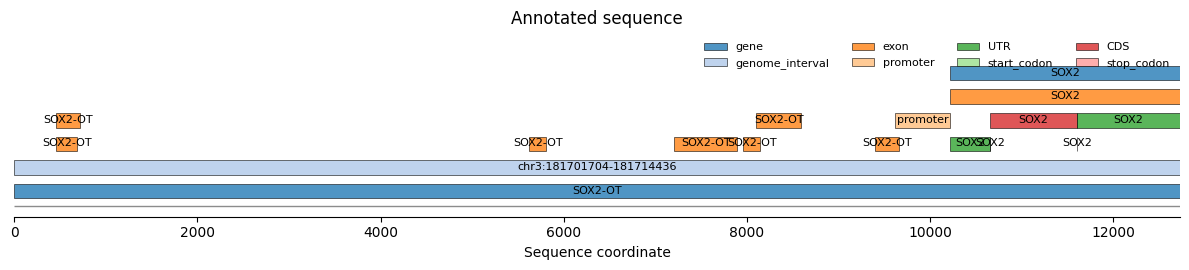

In [10]:
sequence.plot_annotations(hide_types=('source', 'transcript'))

## 8. Generate the mutation library

### Create an in-silico mutagenesis experiment

`ISM` defines the reference sequence, mutation region, model center, and experimental condition:

- `sequence` is the original `AnnotatedSequence`.
- `center` is the sequence-local tokenization center. It may also be a feature name or `Feature`.
- `region` identifies where mutations are allowed. It may be a `(start, end)` tuple, a `Feature`, or a feature name.
- `condition` is the metadata or `Condition` used for model inference.
- `n_substitutions=None` generates all three possible alternative bases at every A/C/G/T position.
- `n_deletions=20` samples 20 distinct single-base deletions.
- `random_seed`, omitted here, defaults to `0` and makes deletion sampling reproducible.
- `center_overlap` controls what happens if a deletion removes the center; its default is `"nearest"`.

The promoter is 600 bp long, so an entirely A/C/G/T promoter produces `600 × 3 = 1,800` substitutions. Together with 20 deletions, the dataframe should contain 1,820 variants. Positions containing ambiguous bases do not generate substitutions.

ISM stores compact mutation descriptions rather than thousands of complete sequence copies. Full annotated reference/alternative pairs are materialized lazily during scoring. Deletions before the TSS shift the center annotation in the alternative allele by one base so that both alleles remain biologically aligned.


In [11]:
ism = ISM(
    sequence = sequence,
    center=NUM_BEFORE*TOKEN_LEN_FOR_FETCH,
    region='promoter',
    condition=lookup['H1'],
    n_deletions=20,
    n_substitutions=None,
)

## 9. Score the ISM library

### Predict the effect of every promoter mutation

`ism.score()` evaluates all pending variants and writes the resulting values directly into `ism.variants`.

`TrackFeatureScorer(features="promoter")` restricts scoring to the annotated promoter. Its relevant defaults are:

- `track="atac"`: use the predicted ATAC accessibility track.
- `aggregate="sum"`: integrate track values across the promoter.
- `sign="alt-ref"`: report alternative minus reference.
- `name="track_feature"`: name of the dataframe column receiving the scores.

The scorer resolves the promoter separately on the reference and alternative alleles. For deletions, the pair coordinate mapper adjusts the alternative promoter interval before aggregating the track.

The execution arguments control different stages:

- `pair_execution="joint"` places each reference and alternative allele together in the same model-forward workflow.
- `max_pairs_per_forward=200` limits each GPU forward to 200 logical pairs, corresponding to as many as 400 physical DNA rows.
- `chunk_size=1600` limits how many variants ISM materializes and submits to the interpreter at once.
- `preprocessing_workers=10` enables parallel CPU preprocessing.
- `prefetch_batches=2` prepares up to two future model batches while the GPU processes the current batch.

With 1,820 variants, ISM uses one chunk of 1,600 and one chunk of 220. Each chunk is divided further into GPU forwards of at most 200 pairs.

ISM requests scalar result retention, extracts the score from each result, and releases the heavier prediction objects. The score is added as a `track_feature` column. If the notebook is interrupted, calling the method again processes only rows where that column is still null.


In [ ]:
ism.score(
    interpreter=interpreter,
    scorer = TrackFeatureScorer(features='promoter'), #sum atac-seq values across 600 bp of promoter feature
    pair_execution='joint',
    preprocessing_workers=10,
    prefetch_batches=2,
    max_pairs_per_forward=200,
    chunk_size=1600
)

Scoring track_feature: 100%|██████████| 2/2 [01:38<00:00, 49.45s/chunk]


In [ ]:
ism.score(
    interpreter=interpreter,
    scorer = TrackWindowScorer(center='variant', width_bp=501), #sum atac-seq values across 501bp window around varinat
    pair_execution='joint',
    preprocessing_workers=10,
    prefetch_batches=2,
    max_pairs_per_forward=200,
    chunk_size=1600
)

Scoring track_window: 100%|██████████| 2/2 [01:52<00:00, 56.40s/chunk]


## 10. Plot all variant effects

### Visualize substitutions and deletions along the promoter

`ism.plot()` creates a lollipop-style plot for one score column.

`scorer_name="track_feature"` selects the column created by `TrackFeatureScorer`. `mutation_type="all"` includes both substitutions and deletions; the other accepted values are `"substitution"` and `"deletion"`.

Alternative nucleotides are represented by color, while reference nucleotides are represented by marker shape. Single-base deletions are shown using the deletion color. Positions are displayed relative to the beginning of the mutated region by default.

The method returns a Matplotlib `(figure, axes)` pair, allowing further customization or saving.


(<Figure size 1600x450 with 1 Axes>,
 array([<Axes: title={'left': 'Model prediction — track_feature'}, xlabel='Position relative to region start (bp)', ylabel='Variant effect'>],
       dtype=object))

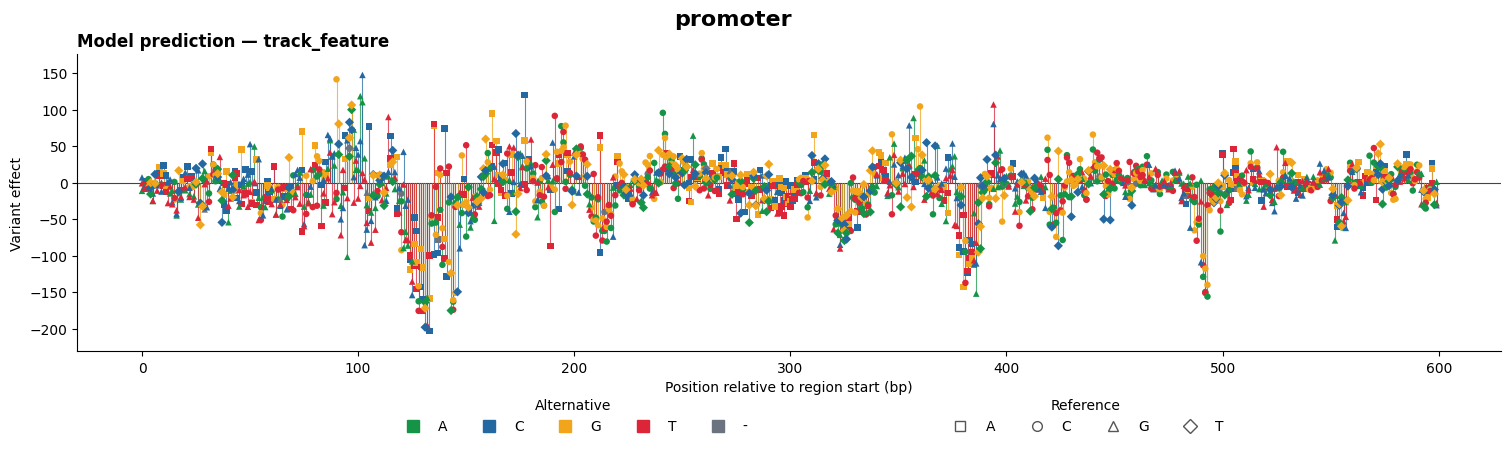

In [26]:
ism.plot(scorer_name='track_feature', mutation_type='all')

(<Figure size 1600x450 with 1 Axes>,
 array([<Axes: title={'left': 'Model prediction — track_window'}, xlabel='Position relative to region start (bp)', ylabel='Variant effect'>],
       dtype=object))

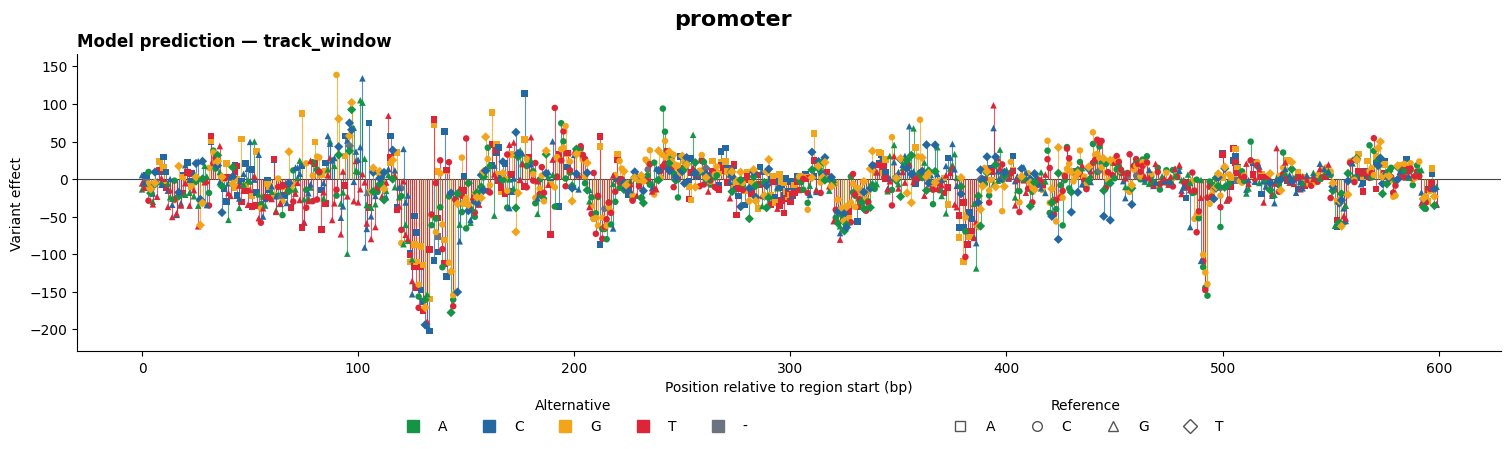

In [32]:
ism.plot(scorer_name='track_window', mutation_type='all')

## 11. Plot the substitution matrix

### Display saturation-mutagenesis scores as a heatmap

`plot_substitution_matrix()` shows substitution effects in a compact matrix:

- The x-axis represents position relative to the promoter start.
- The y-axis represents the alternative nucleotide: A, C, G, or T.
- Cell color represents the value of `track_feature`.
- The default color scale is centered at zero, separating positive and negative predicted effects.

The reference nucleotide at each position has no corresponding mutation and therefore appears as an empty cell. Deletions are intentionally excluded because they do not have an alternative nucleotide row.

The method accepts optional `cmap`, `center`, and `figsize` arguments and returns a Matplotlib `(figure, axis)` pair.

(<Figure size 1600x400 with 2 Axes>,
 <Axes: title={'center': 'promoter — track_feature'}, xlabel='Position relative to region start (bp)', ylabel='Alternative base'>)

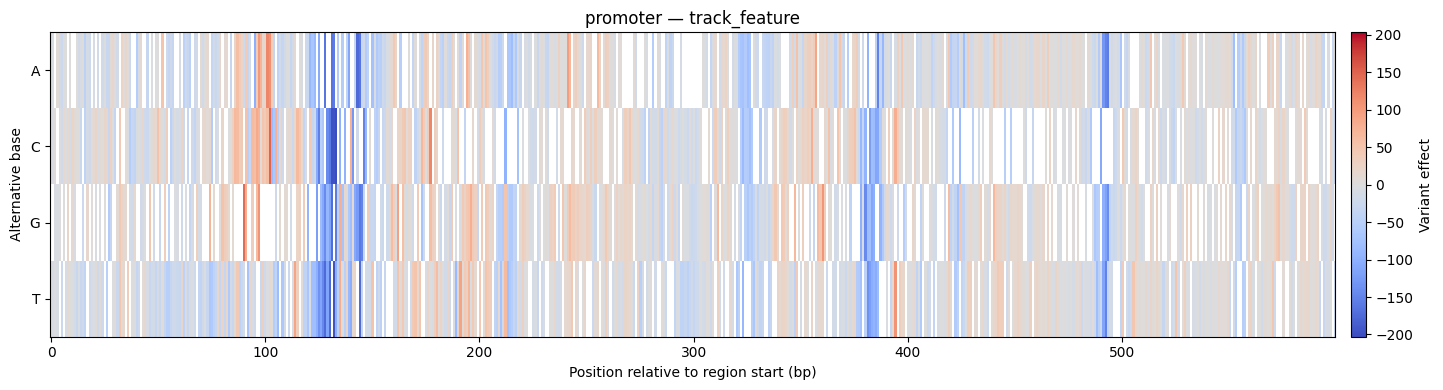

In [17]:
ism.plot_substitution_matrix(scorer_name='track_feature')

(<Figure size 1600x400 with 2 Axes>,
 <Axes: title={'center': 'promoter — track_window'}, xlabel='Position relative to region start (bp)', ylabel='Alternative base'>)

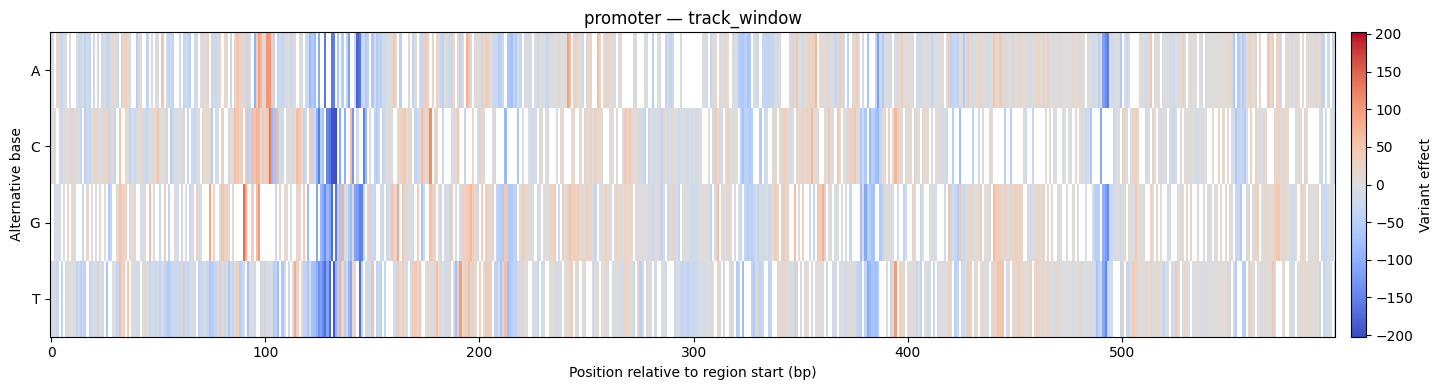

In [34]:
ism.plot_substitution_matrix(scorer_name='track_window')

## 12. Inspect the results dataframe

### Examine mutation metadata and accumulated scores

`ism.variants` is the Polars dataframe containing the mutation library and every score added so far.

Each row represents one substitution or deletion. Structural columns include the variant identifier, mutation type, sequence-local position, position relative to the promoter, reference and alternative alleles, and available source-genome coordinates.

After scoring, the dataframe also contains a `track_feature` column. A null value means that the corresponding mutation has not yet been scored. Additional calls with differently named scorers append additional score columns to this same dataframe.


In [33]:
ism.variants

variant_id,mutation_type,position,end,position_in_region,ref,alt,length,source,source_position,source_chrom,source_strand,track_feature,track_window
str,str,i64,i64,i64,str,str,i64,str,i64,str,str,f64,f64
"""sub_9620_G_A""","""substitution""",9620,9621,0,"""G""","""A""",1,"""genome""",181711324,"""chr3""","""+""",-11.070312,-13.726562
"""sub_9620_G_C""","""substitution""",9620,9621,0,"""G""","""C""",1,"""genome""",181711324,"""chr3""","""+""",7.2734375,5.2734375
"""sub_9620_G_T""","""substitution""",9620,9621,0,"""G""","""T""",1,"""genome""",181711324,"""chr3""","""+""",-0.765625,-5.703125
"""sub_9621_G_A""","""substitution""",9621,9622,1,"""G""","""A""",1,"""genome""",181711325,"""chr3""","""+""",-5.546875,-6.296875
"""sub_9621_G_C""","""substitution""",9621,9622,1,"""G""","""C""",1,"""genome""",181711325,"""chr3""","""+""",-6.820312,-5.265625
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""sub_10218_T_C""","""substitution""",10218,10219,598,"""T""","""C""",1,"""genome""",181711922,"""chr3""","""+""",-9.257812,-13.527344
"""sub_10218_T_G""","""substitution""",10218,10219,598,"""T""","""G""",1,"""genome""",181711922,"""chr3""","""+""",-15.296875,-23.121094
"""sub_10219_G_A""","""substitution""",10219,10220,599,"""G""","""A""",1,"""genome""",181711923,"""chr3""","""+""",1.4140625,-10.132812


## 13. Find the strongest predicted effects

### Rank mutations by effect magnitude

`ism.top()` returns the variants with the strongest finite values for a selected scorer.

`scorer_name` identifies the dataframe column to rank. By default:

- `n=20` returns the top 20 variants.
- `absolute=True` ranks by absolute score, so both strong positive and strong negative effects are included.

To retrieve only the largest positive effects, use `absolute=False`. The returned object is another Polars dataframe and includes both the mutation metadata and all available score columns.

In [19]:
ism.top(scorer_name='track_feature')

variant_id,mutation_type,position,end,position_in_region,ref,alt,length,source,source_position,source_chrom,source_strand,track_feature
str,str,i64,i64,i64,str,str,i64,str,i64,str,str,f64
"""sub_9753_A_C""","""substitution""",9753,9754,133,"""A""","""C""",1,"""genome""",181711457,"""chr3""","""+""",-202.972656
"""sub_9751_T_C""","""substitution""",9751,9752,131,"""T""","""C""",1,"""genome""",181711455,"""chr3""","""+""",-197.867188
"""sub_9752_G_C""","""substitution""",9752,9753,132,"""G""","""C""",1,"""genome""",181711456,"""chr3""","""+""",-196.171875
"""sub_9752_G_T""","""substitution""",9752,9753,132,"""G""","""T""",1,"""genome""",181711456,"""chr3""","""+""",-194.957031
"""sub_9750_A_T""","""substitution""",9750,9751,130,"""A""","""T""",1,"""genome""",181711454,"""chr3""","""+""",-175.640625
…,…,…,…,…,…,…,…,…,…,…,…,…
"""sub_9752_G_A""","""substitution""",9752,9753,132,"""G""","""A""",1,"""genome""",181711456,"""chr3""","""+""",-157.414062
"""sub_10113_C_A""","""substitution""",10113,10114,493,"""C""","""A""",1,"""genome""",181711817,"""chr3""","""+""",-155.867188
"""sub_9745_G_C""","""substitution""",9745,9746,125,"""G""","""C""",1,"""genome""",181711449,"""chr3""","""+""",-153.820312
